# 관련성 체크 추가

이번 튜토리얼에서는 Naive RAG에 **관련성 체크(Groundedness Check)** 단계를 추가합니다.

> 참고 문서: [LangGraph Graph API](https://docs.langchain.com/oss/python/langgraph/graph-api)

**학습 목표**

- 검색된 문서와 질문의 관련성을 평가하는 방법을 학습합니다.
- 조건부 엣지를 활용하여 관련성에 따른 분기 처리를 구현합니다.
- 재귀 상태 방지를 위한 `recursion_limit` 설정 방법을 익힙니다.

**참고**

- 이전 튜토리얼에서 확장된 내용이므로, 겹치는 부분은 간략히 설명합니다.

![langgraph-add-relevance-check](assets/langgraph-add-relevance-check.png)

## 환경 설정

먼저 필요한 환경 변수를 로드하고 LangSmith 추적을 설정합니다. `.env` 파일에는 사용할 LLM 제공자의 API 키가 저장되어 있어야 합니다. LangSmith 추적을 활성화하면 그래프 실행 과정을 시각적으로 디버깅할 수 있습니다.

아래 코드는 환경 변수를 로드하고 LangSmith 프로젝트를 설정합니다.

In [1]:
# API 키를 환경변수로 관리하기 위한 설정 파일
from dotenv import load_dotenv

# API 키 정보 로드
load_dotenv(override=True)

True

In [2]:
# LangSmith 추적을 설정합니다.
from langchain_teddynote import logging

# 프로젝트 이름을 입력합니다.
logging.langsmith("LangGraph-RAG")

LangSmith 추적을 시작합니다.
[프로젝트명]
LangGraph-RAG


## PDF 기반 Retrieval Chain 생성

PDF 문서를 기반으로 Retrieval Chain을 생성합니다. LangGraph에서는 Retriever와 Chain을 분리하여 각 노드에서 세부 처리를 수행할 수 있습니다. 이 구조를 활용하면 검색과 생성 사이에 관련성 체크 같은 중간 단계를 자연스럽게 삽입할 수 있습니다.

**사용 문서**

- 소프트웨어정책연구소(SPRi) - 2023년 12월호
- 파일명: `SPRI_AI_Brief_2023년12월호_F.pdf`

아래 코드는 PDF 문서를 로드하고 Retriever와 Chain을 생성합니다.

In [3]:
from rag.pdf import PDFRetrievalChain

# PDF 문서를 로드합니다.
pdf = PDFRetrievalChain(["data/SPRI_AI_Brief_2023년12월호_F.pdf"]).create_chain()

# retriever와 chain을 생성합니다.
pdf_retriever = pdf.retriever
pdf_chain = pdf.chain

Cache configured for multi-PDF processing
Loading PDF: data/SPRI_AI_Brief_2023년12월호_F.pdf
Successfully loaded 23 pages from: data/SPRI_AI_Brief_2023년12월호_F.pdf

Loading Summary:
- Successfully loaded: 1 files
- Failed to load: 0 files
- Total documents loaded: 23
FAISS index saved to cache


## State 정의

`State`는 그래프의 노드 간에 공유되는 상태를 정의합니다. 각 노드는 State를 입력으로 받아 처리 후 업데이트된 State를 반환하며, 이를 통해 노드 간 데이터 전달이 이루어집니다.

이번에는 **관련성(relevance)** 체크 결과를 저장하는 필드를 추가합니다. 이 필드는 `"yes"` 또는 `"no"` 값을 저장하며, 조건부 엣지에서 다음 노드를 결정하는 데 사용됩니다.

아래 코드에서는 기본 RAG 상태에 `relevance` 필드를 추가한 `GraphState`를 정의합니다.

In [4]:
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages


# GraphState 상태 정의
class GraphState(TypedDict):
    question: Annotated[str, "Question"]  # 사용자 질문
    context: Annotated[str, "Context"]  # 검색된 문서
    answer: Annotated[str, "Answer"]  # 생성된 답변
    messages: Annotated[list, add_messages]  # 대화 히스토리 (누적)
    relevance: Annotated[str, "Relevance"]  # 관련성 체크 결과 (yes/no)

## 노드(Node) 정의

노드는 각 단계를 처리하는 함수입니다. State를 입력으로 받아 처리 후 업데이트된 State를 반환합니다. 기존 Naive RAG의 노드에 **관련성 체크 노드**를 추가하여, 검색된 문서가 질문과 관련이 있는지 평가하는 단계를 삽입합니다.

**노드 목록**

- `retrieve_document`: 문서를 검색합니다.
- `relevance_check`: 검색된 문서와 질문의 관련성을 평가합니다.
- `llm_answer`: 검색된 문서를 기반으로 답변을 생성합니다.

**라우팅 함수**

- `is_relevant`: 조건부 엣지에서 사용되는 함수로, `relevance` 상태 값에 따라 다음 노드를 결정합니다.

아래 코드에서는 각 노드 함수와 라우팅 함수를 정의합니다. 관련성 평가에는 `GroundednessChecker`를 사용하며, 경량 모델로 비용 효율적인 평가를 수행합니다.

In [ ]:
from langchain.chat_models import init_chat_model
from langchain_teddynote.evaluator import GroundednessChecker
from langchain_teddynote.messages import messages_to_history
from rag.utils import format_docs


def retrieve_document(state: GraphState) -> GraphState:
    """문서를 검색하는 노드입니다.
    
    사용자 질문을 기반으로 관련 문서를 검색하고 포맷팅합니다.
    """
    # 질문을 상태에서 가져옵니다.
    latest_question = state["question"]

    # 문서에서 검색하여 관련성 있는 문서를 찾습니다.
    retrieved_docs = pdf_retriever.invoke(latest_question)

    # 검색된 문서를 형식화합니다. (프롬프트 입력용)
    retrieved_docs = format_docs(retrieved_docs)

    # 검색된 문서를 context 키에 저장합니다.
    return {"context": retrieved_docs}


def llm_answer(state: GraphState) -> GraphState:
    """답변을 생성하는 노드입니다.
    
    검색된 문서와 대화 기록을 기반으로 답변을 생성합니다.
    """
    # 질문을 상태에서 가져옵니다.
    latest_question = state["question"]

    # 검색된 문서를 상태에서 가져옵니다.
    context = state["context"]

    # 체인을 호출하여 답변을 생성합니다.
    response = pdf_chain.invoke(
        {
            "question": latest_question,
            "context": context,
            "chat_history": messages_to_history(state["messages"]),
        }
    )

    # 생성된 답변과 메시지를 상태에 저장합니다.
    return {
        "answer": response,
        "messages": [("user", latest_question), ("assistant", response)],
    }


def relevance_check(state: GraphState) -> GraphState:
    """관련성을 체크하는 노드입니다.
    
    검색된 문서가 질문과 관련이 있는지 평가합니다.
    """
    # 관련성 평가기를 생성합니다.
    # When using an OpenAI key, change to models like gpt-4.1-mini, gpt-4.1-nano etc.
    question_retrieval_relevant = GroundednessChecker(
        llm=init_chat_model("claude-sonnet-4-5", temperature=0),
        target="question-retrieval"
    ).create()

    # 관련성 체크를 실행합니다. ("yes" 또는 "no")
    response = question_retrieval_relevant.invoke(
        {"question": state["question"], "context": state["context"]}
    )

    print("==== [RELEVANCE CHECK] ====")
    print(response.score)

    # 관련성 결과를 상태에 저장합니다.
    return {"relevance": response.score}


def is_relevant(state: GraphState) -> str:
    """조건부 엣지에서 사용되는 라우팅 함수입니다.
    
    관련성 여부에 따라 다음 노드를 결정합니다.
    """
    if state["relevance"] == "yes":
        return "relevant"
    else:
        return "not relevant"

## 그래프 생성

노드를 추가하고 **조건부 엣지**를 사용하여 관련성에 따른 분기 처리를 구현합니다. 조건부 엣지는 `add_conditional_edges` 메서드로 정의하며, 라우팅 함수의 반환값에 따라 다음 노드를 동적으로 결정합니다. 이를 통해 관련성 체크 결과에 따라 답변 생성 또는 재검색으로 분기할 수 있습니다.

- 관련성이 있으면(`relevant`): 답변을 생성합니다.
- 관련성이 없으면(`not relevant`): 다시 검색합니다.

아래 코드에서는 `START`에서 시작하여 검색, 관련성 체크, 답변 생성으로 이어지는 그래프를 구성합니다.

In [6]:
from langgraph.graph import END, START, StateGraph
from langgraph.checkpoint.memory import MemorySaver

# 그래프 정의
workflow = StateGraph(GraphState)

# 노드 추가
workflow.add_node("retrieve", retrieve_document)
workflow.add_node("relevance_check", relevance_check)  # 관련성 체크 노드 추가
workflow.add_node("llm_answer", llm_answer)

# 엣지 추가
workflow.add_edge(START, "retrieve")  # 시작 -> 검색
workflow.add_edge("retrieve", "relevance_check")  # 검색 -> 관련성 체크

# 조건부 엣지 추가 (관련성에 따른 분기)
workflow.add_conditional_edges(
    "relevance_check",  # 관련성 체크 노드에서 분기
    is_relevant,  # 라우팅 함수
    {
        "relevant": "llm_answer",  # 관련성이 있으면 답변 생성
        "not relevant": "retrieve",  # 관련성이 없으면 재검색
    },
)

workflow.add_edge("llm_answer", END)  # 답변 -> 종료

# 체크포인터 설정 (대화 기록 저장)
memory = MemorySaver()

# 그래프 컴파일
app = workflow.compile(checkpointer=memory)

### 그래프 시각화

컴파일한 그래프를 시각화합니다. 시각화를 통해 노드 간의 연결 관계와 조건부 분기 흐름을 직관적으로 확인할 수 있습니다. 관련성 체크 노드에서 `relevant`와 `not relevant` 두 경로로 분기되는 구조가 표시됩니다.

아래 코드는 컴파일된 그래프를 시각화합니다.

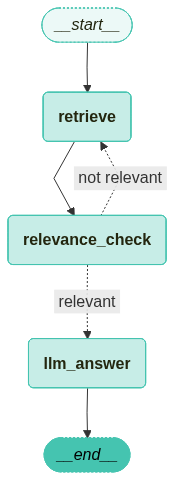

In [7]:
from langchain_teddynote.graphs import visualize_graph

# 그래프 시각화
visualize_graph(app)

## 그래프 실행

그래프를 실행하여 관련성 체크가 포함된 RAG 파이프라인을 테스트합니다. `invoke_graph`와 `stream_graph` 함수를 사용하여 각각 일괄 실행과 스트리밍 출력을 수행할 수 있습니다. `recursion_limit`을 설정하면 관련성 체크 실패 시 반복되는 재검색 횟수를 제한할 수 있습니다.

아래 코드에서는 PDF 문서에 관련성이 있는 질문으로 그래프를 실행합니다.

In [10]:
from langchain_core.runnables import RunnableConfig
from langchain_teddynote.messages import stream_graph, invoke_graph, random_uuid

# config 설정 (재귀 최대 횟수, thread_id)
config = RunnableConfig(recursion_limit=20, configurable={"thread_id": random_uuid()})

# 질문 입력 (관련성 있는 질문)
inputs = GraphState(question="앤스로픽에 투자한 기업과 투자금액을 알려주세요.")

# 그래프 실행
invoke_graph(app, inputs, config, node_names=["relevance_check", "llm_answer"])

==== [RELEVANCE CHECK] ====
yes

🔄 Node: relevance_check 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
relevance:
yes

🔄 Node: llm_answer 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
answer:
앤스로픽에 투자한 기업과 투자금액은 다음과 같습니다.

- 구글: 최대 20억 달러 투자 합의 (2023년 10월 27일), 이 중 5억 달러 우선 투자, 2023년 2월에 이미 5억 5,000만 달러 투자
- 아마존: 최대 40억 달러 투자 계획 공개 (2023년 9월)
- 마이크로소프트: 직접적인 앤스로픽 투자는 없으며, 오픈AI에 30억 달러 투자 후 2023년 1월에 추가 100억 달러 투자

즉, 앤스로픽에 직접 투자한 기업은 구글과 아마존이며, 구글은 총 최대 20억 달러, 아마존은 최대 40억 달러를 투자할 계획입니다.

**Source**
- data/SPRI_AI_Brief_2023년12월호_F.pdf (page 14)
('user', '앤스로픽에 투자한 기업과 투자금액을 알려주세요.')
('assistant', '앤스로픽에 투자한 기업과 투자금액은 다음과 같습니다.\n\n- 구글: 최대 20억 달러 투자 합의 (2023년 10월 27일), 이 중 5억 달러 우선 투자, 2023년 2월에 이미 5억 5,000만 달러 투자\n- 아마존: 최대 40억 달러 투자 계획 공개 (2023년 9월)\n- 마이크로소프트: 직접적인 앤스로픽 투자는 없으며, 오픈AI에 30억 달러 투자 후 2023년 1월에 추가 100억 달러 투자\n\n즉, 앤스로픽에 직접 투자한 기업은 구글과 아마존이며, 구글은 총 최대 20억 달러, 아마존은 최대 40억 달러를 투자할 계획입니다.\n\n**Source**\n- data/SPRI_AI_Brief_2023년12월호_F.pdf (page 14)')


In [11]:
# 그래프 스트리밍 출력
stream_graph(app, inputs, config, node_names=["relevance_check", "llm_answer"])


🔄 Node: relevance_check 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
==== [RELEVANCE CHECK] ====
yes

🔄 Node: llm_answer 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
앤스로픽에 투자한 기업과 투자금액은 다음과 같습니다.

- 구글: 최대 20억 달러 투자 합의 (2023년 10월 27일), 이 중 5억 달러를 우선 투자했으며, 2023년 2월에 이미 5억 5,000만 달러 투자
- 아마존: 최대 40억 달러 투자 계획 공개 (2023년 9월)
- 마이크로소프트: 직접적인 앤스로픽 투자는 없으나, 오픈AI에 30억 달러 투자 후 2023년 1월에 추가 100억 달러 투자

즉, 앤스로픽에 직접 투자한 주요 기업은 구글과 아마존이며, 구글은 총 20억 달러, 아마존은 최대 40억 달러를 투자할 계획입니다.

**Source**
- data/SPRI_AI_Brief_2023년12월호_F.pdf (page 14)

### 결과 확인

그래프 실행 후 최종 상태를 확인합니다. `get_state` 메서드를 사용하면 현재 체크포인트에 저장된 모든 상태 값을 조회할 수 있습니다. 질문, 답변과 함께 관련성 체크 결과(`relevance`)도 확인할 수 있습니다.

아래 코드는 최종 상태에서 질문과 답변을 출력합니다.

In [12]:
# 최종 상태 조회
outputs = app.get_state(config).values

print(f'Question: {outputs["question"]}')
print("===" * 20)
print(f'Answer:\n{outputs["answer"]}')

Question: 앤스로픽에 투자한 기업과 투자금액을 알려주세요.
Answer:
앤스로픽에 투자한 기업과 투자금액은 다음과 같습니다.

- 구글: 최대 20억 달러 투자 합의 (2023년 10월 27일), 이 중 5억 달러를 우선 투자했으며, 2023년 2월에 이미 5억 5,000만 달러 투자
- 아마존: 최대 40억 달러 투자 계획 공개 (2023년 9월)
- 마이크로소프트: 직접적인 앤스로픽 투자는 없으나, 오픈AI에 30억 달러 투자 후 2023년 1월에 추가 100억 달러 투자

즉, 앤스로픽에 직접 투자한 주요 기업은 구글과 아마존이며, 구글은 총 20억 달러, 아마존은 최대 40억 달러를 투자할 계획입니다.

**Source**
- data/SPRI_AI_Brief_2023년12월호_F.pdf (page 14)


In [13]:
# 관련성 체크 결과 확인
print(f'Relevance: {outputs["relevance"]}')

Relevance: yes


## 재귀 상태 처리

검색 결과의 `relevance_check`가 실패할 경우, 동일한 쿼리가 반복적으로 검색되어 **재귀 상태**에 빠질 수 있습니다. LangGraph에서는 이러한 무한 루프를 방지하기 위한 메커니즘을 제공합니다.

이를 방지하기 위해:

1. `recursion_limit`을 설정하여 최대 재귀 횟수를 제한합니다.
2. `GraphRecursionError`를 처리하여 무한 루프를 방지합니다.

다음 튜토리얼에서는 **웹 검색**을 추가하여 이 문제를 해결합니다.

> 참고 문서: [LangGraph Graph API](https://docs.langchain.com/oss/python/langgraph/graph-api.md)

아래 코드에서는 PDF 문서에 없는 정보를 질문하여 의도적으로 재귀 상태를 유발하고, `GraphRecursionError`로 처리하는 방법을 보여줍니다.

In [15]:
from langgraph.errors import GraphRecursionError
from langchain_core.runnables import RunnableConfig

# config 설정 (재귀 최대 횟수 제한)
config = RunnableConfig(recursion_limit=10, configurable={"thread_id": random_uuid()})

# 질문 입력 (관련성 없는 질문 - 재귀 상태 유발)
inputs = GraphState(question="테디노트의 랭체인 튜토리얼에 대한 정보를 알려주세요.")

try:
    # 그래프 실행
    stream_graph(app, inputs, config, node_names=["retrieve", "relevance_check", "llm_answer"])
except GraphRecursionError as recursion_error:
    print(f"GraphRecursionError: {recursion_error}")


🔄 Node: relevance_check 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
==== [RELEVANCE CHECK] ====
no
==== [RELEVANCE CHECK] ====
no
==== [RELEVANCE CHECK] ====
no
==== [RELEVANCE CHECK] ====
no
==== [RELEVANCE CHECK] ====
no
GraphRecursionError: Recursion limit of 10 reached without hitting a stop condition. You can increase the limit by setting the `recursion_limit` config key.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/GRAPH_RECURSION_LIMIT


## 정리

이 튜토리얼에서는 Naive RAG에 **관련성 체크** 단계를 추가했습니다.

### 핵심 개념

1. **GroundednessChecker**: 검색된 문서와 질문의 관련성을 평가합니다.
2. **조건부 엣지**: 관련성 결과에 따라 분기 처리를 수행합니다.
3. **재귀 상태 방지**: `recursion_limit`과 `GraphRecursionError` 처리로 무한 루프를 방지합니다.

### 다음 단계

다음 튜토리얼에서는 관련성이 없을 경우 웹 검색(Web Search)을 수행하여 더 나은 답변을 생성하는 방법을 학습합니다.